In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE = "/content/drive/MyDrive/data-analysis"

INPUT_FILE = f"{BASE}/data/DailyDelhiClimateTrain.csv"

OUTPUT_DATA = f"{BASE}/outputs/processed_data"
OUTPUT_FIG  = f"{BASE}/outputs/figures"

os.makedirs(OUTPUT_DATA, exist_ok=True)
os.makedirs(OUTPUT_FIG, exist_ok=True)

In [4]:
df = pd.read_csv(INPUT_FILE)

df['date'] = pd.to_datetime(df['date'])

print("Initial shape:", df.shape)

Initial shape: (1462, 5)


In [5]:
print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Duplicates ===")
duplicates = df.duplicated().sum()
print("Number of duplicates:", duplicates)


=== Missing values ===
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

=== Duplicates ===
Number of duplicates: 0


In [6]:
def check_physical_ranges(df):

    rules = {
        "meantemp": (-10, 60),
        "humidity": (0, 100),
        "wind_speed": (0, 150),
        "meanpressure": (980, 1080)
    }

    for col, (low, high) in rules.items():
        invalid = df[(df[col] < low) | (df[col] > high)]

        print(f"\n=== {col} ===")
        print(f"Invalid values: {len(invalid)}")

        if len(invalid) > 0:
            print(invalid[['date', col]].head())

print("\n🔍 Physical validation")
check_physical_ranges(df)


🔍 Physical validation

=== meantemp ===
Invalid values: 0

=== humidity ===
Invalid values: 0

=== wind_speed ===
Invalid values: 0

=== meanpressure ===
Invalid values: 9
           date  meanpressure
1182 2016-03-28   7679.333333
1255 2016-06-09    938.066667
1300 2016-07-24    946.312500
1309 2016-08-02    310.437500
1321 2016-08-14    633.900000


In [7]:
df.loc[(df['meanpressure'] < 980) | (df['meanpressure'] > 1080), 'meanpressure'] = np.nan

In [8]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return outliers, lower, upper

parameters = ["meantemp", "humidity", "wind_speed", "meanpressure"]

outliers_dict = {}

for param in parameters:
    outliers, low, up = detect_outliers(df, param)
    outliers_dict[param] = outliers

    print(f"\n{param}:")
    print(f"Lower bound: {low}, Upper bound: {up}")
    print(f"Outliers count: {len(outliers)}")


meantemp:
Lower bound: 0.18415178571428825, Upper bound: 49.97879464285714
Outliers count: 0

humidity:
Lower bound: 17.609375, Upper bound: 104.984375
Outliers count: 2

wind_speed:
Lower bound: -5.169852941176471, Upper bound: 17.883088235294117
Outliers count: 30

meanpressure:
Lower bound: 981.65625, Upper bound: 1034.90625
Outliers count: 0


In [9]:
df['month'] = df['date'].dt.to_period('M')

monthly_mean = df.groupby('month')[parameters].mean().reset_index()

monthly_mean['month'] = monthly_mean['month'].dt.to_timestamp()

monthly_mean.to_csv(f"{OUTPUT_DATA}/monthly_mean.csv", index=False)

In [10]:
all_outliers = pd.DataFrame()

for param in parameters:
    temp = outliers_dict[param][['date', param]].copy()
    temp['parameter'] = param
    all_outliers = pd.concat([all_outliers, temp])

all_outliers.to_csv(f"{OUTPUT_DATA}/outliers.csv", index=False)

In [11]:
units = {
    "meantemp": "Temperature (°C)",
    "humidity": "Humidity (%)",
    "wind_speed": "Wind speed (km/h)",
    "meanpressure": "Pressure (hPa)"
}

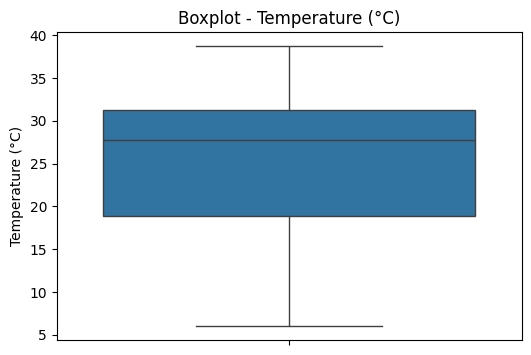

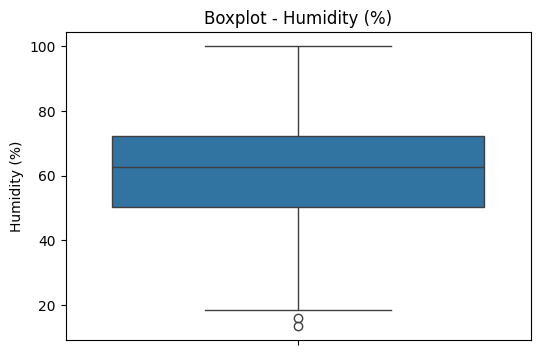

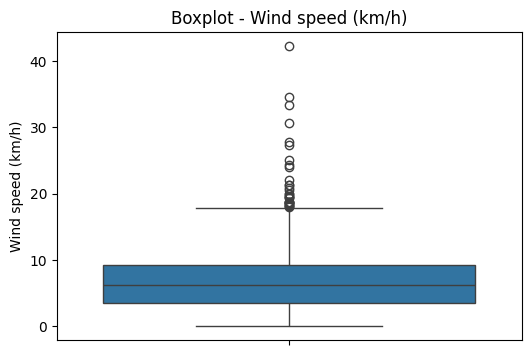

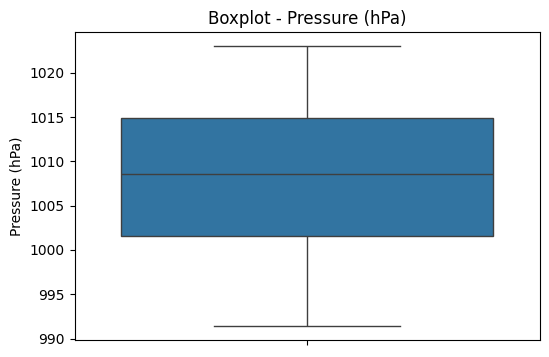

In [12]:
for param in parameters:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, y=param)

    plt.title(f"Boxplot - {units[param]}")
    plt.ylabel(units[param])

    plt.savefig(f"{OUTPUT_FIG}/boxplot_{param}.png", dpi=300)
    plt.show()
    plt.close()

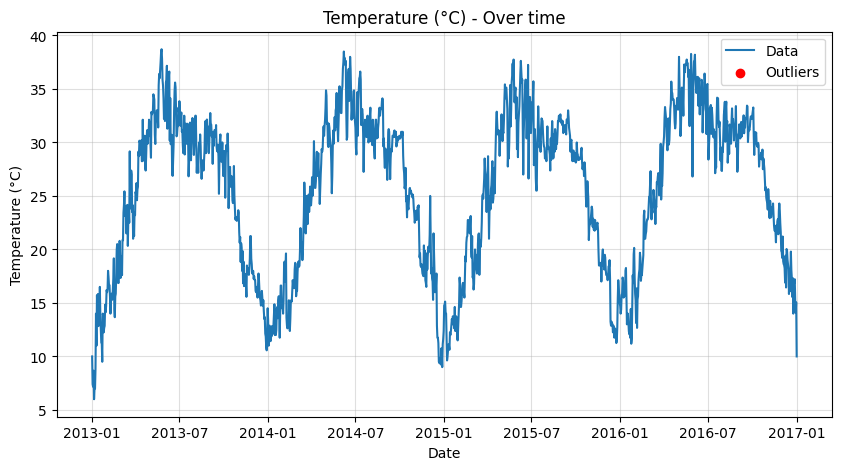

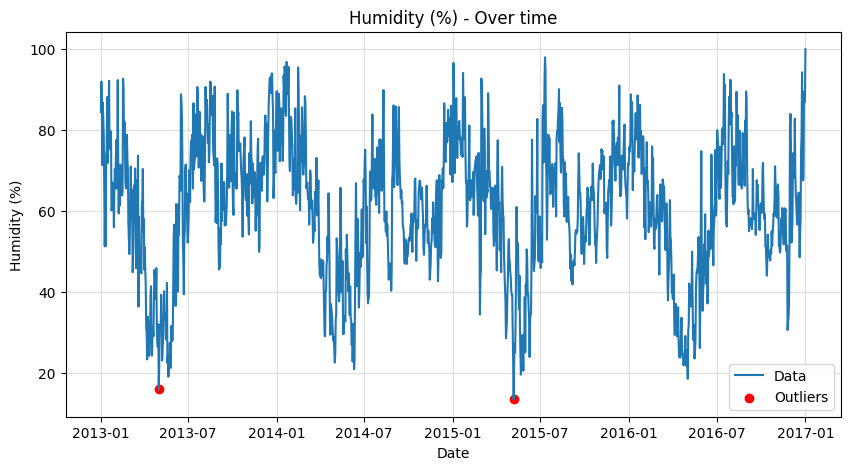

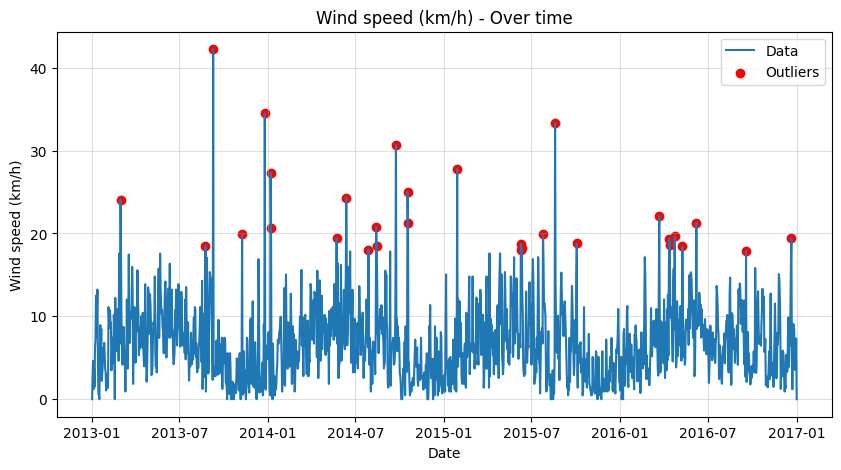

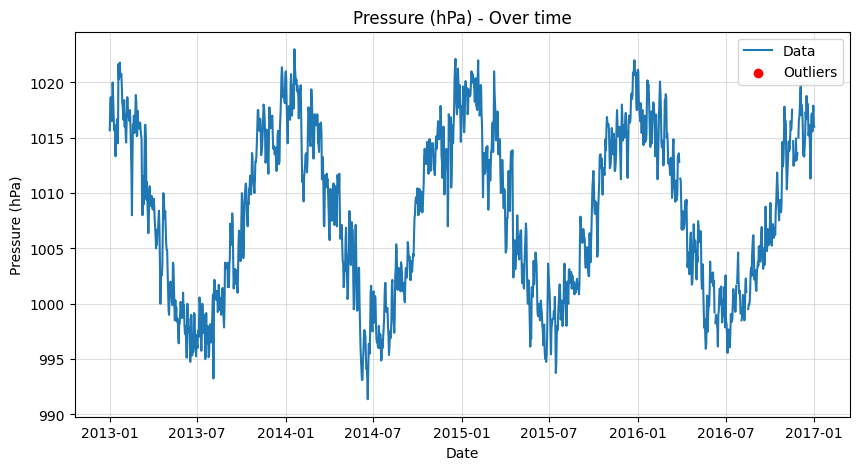

In [13]:
for param in parameters:
    plt.figure(figsize=(10,5))
    plt.grid(alpha=0.4)

    plt.plot(df['date'], df[param], label="Data")

    outliers = outliers_dict[param]
    plt.scatter(outliers['date'], outliers[param], color='red', label="Outliers")

    plt.title(f"{units[param]} - Over time")
    plt.xlabel("Date")
    plt.ylabel(units[param])

    plt.legend()

    plt.savefig(f"{OUTPUT_FIG}/timeseries_outliers_{param}.png", dpi=300)
    plt.show()
    plt.close()

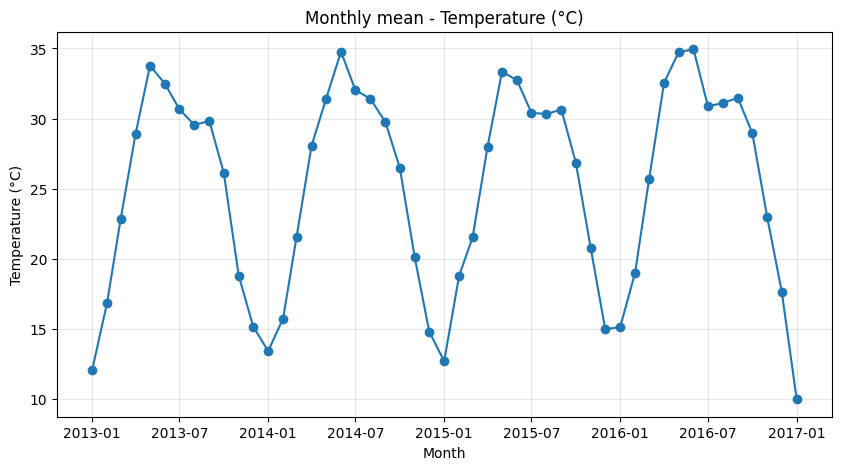

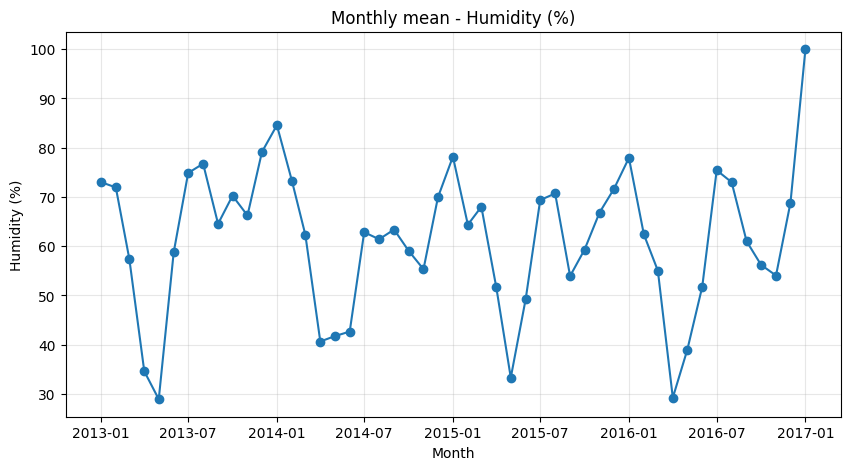

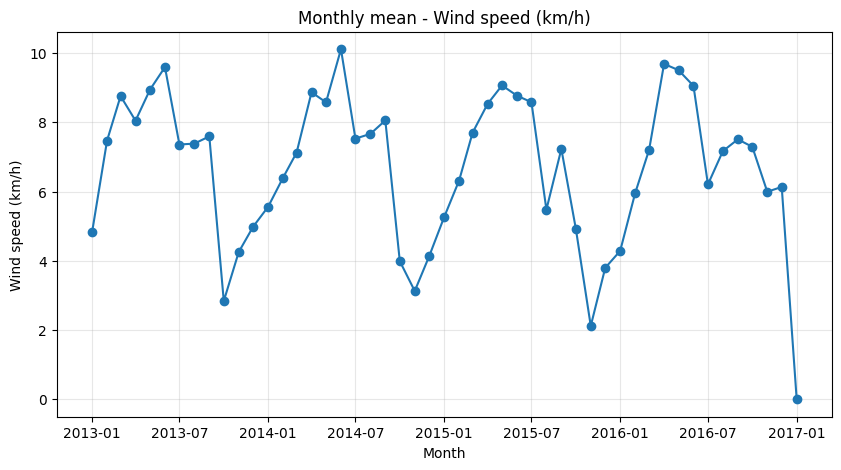

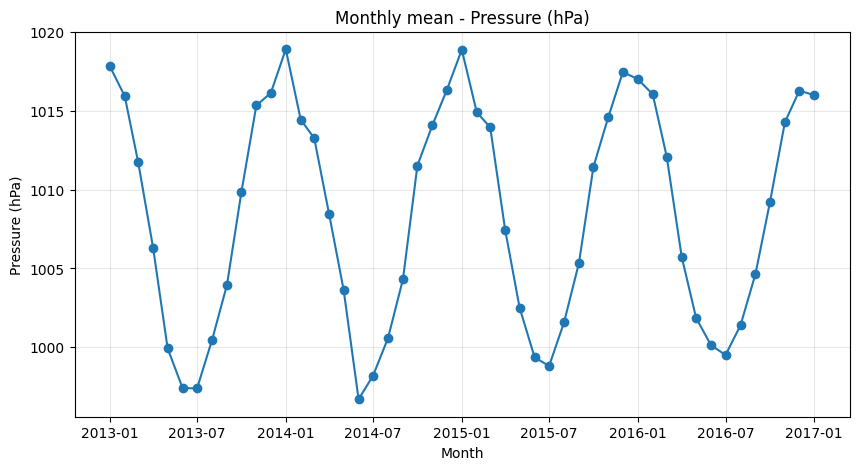

In [14]:
for param in parameters:
    plt.figure(figsize=(10,5))
    plt.grid(alpha=0.3)

    plt.plot(monthly_mean['month'], monthly_mean[param], marker='o')

    plt.title(f"Monthly mean - {units[param]}")
    plt.xlabel("Month")
    plt.ylabel(units[param])

    plt.savefig(f"{OUTPUT_FIG}/monthly_mean_{param}.png", dpi=300)
    plt.show()
    plt.close()

In [15]:
del df
gc.collect()

print("\n Analysis completed successfully!")


 Analysis completed successfully!
